# Extended ViT: ResNet18 + Transformer hybrid

CNN-as-tokenizer hybrid architecture (the pattern from the original ViT paper's appendix):
ResNet18's conv backbone produces a 7x7x512 feature map, flattened into 49 tokens, with a
learnable [CLS] token and positional embeddings, fed through a Transformer encoder. Classifies
from the [CLS] token's output. Trains on the same merged 256-class dataset (RAS-Compound +
Ekush + MatriVasha) as `merged-training.ipynb`, with its CNN backbone warm-started from
`resnet18_merged.pth`.

Saves `extended_vit_merged.pth` — same schema as `resnet18_merged.pth` plus an `"arch"` field,
so `predict_word.py --model extended_vit_merged.pth` works unchanged (it picks the right
architecture from that field automatically).

Trains on GPU (MPS) but must run inference on CPU — benchmarked at 10.3ms/image on CPU, so
that's not a concern.

Run `caffeinate -i` in a terminal before starting the training cell — multi-hour run, and
macOS will otherwise sleep and pause it.

In [1]:
import time
from copy import deepcopy
from pathlib import Path

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

from train_merged import (
    IMG_SIZE, BEST_CHECKPOINT as RESNET_CHECKPOINT,
    build_manifest, stratified_split, CharDataset, build_transforms,
    pick_device, run_epoch, build_extended_vit,
)

BEST_CHECKPOINT = Path("checkpoints/extended_vit_merged.pth")
LAST_CHECKPOINT = Path("checkpoints/extended_vit_merged_last.pth")
ARCH = "extended_vit"


In [2]:
t0 = time.time()
samples, classes = build_manifest()
NUM_CLASSES = len(classes)
print(f"{len(samples)} images, {NUM_CLASSES} classes, scanned in {time.time()-t0:.1f}s")


681309 images, 256 classes, scanned in 2.3s


In [3]:
# LIMIT_PER_CLASS = None uses everything (~681K images, ~10-13h on this Mac's GPU per 8 epochs).
# Set e.g. LIMIT_PER_CLASS = 300 for a much faster ~2-4h run if you want to iterate first.
LIMIT_PER_CLASS = None

train_samples, val_samples, test_samples = stratified_split(samples, limit_per_class=LIMIT_PER_CLASS)
print(f"Train {len(train_samples)} | Val {len(val_samples)} | Test {len(test_samples)}")


Train 545289 | Val 68010 | Test 68010


In [4]:
train_tf, eval_tf = build_transforms()

BATCH_SIZE = 32
NUM_WORKERS = 4  # safe: CharDataset/PolarityNormalize come from train_merged.py, a real importable module

train_loader = DataLoader(CharDataset(train_samples, train_tf), batch_size=BATCH_SIZE,
                           shuffle=True, num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0)
val_loader = DataLoader(CharDataset(val_samples, eval_tf), batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0)
test_loader = DataLoader(CharDataset(test_samples, eval_tf), batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, persistent_workers=NUM_WORKERS > 0)


In [5]:
device = pick_device()  # MPS on this Mac for training; predict_word.py always runs inference on CPU
print("Device:", device)

model = build_extended_vit(NUM_CLASSES, device, warm_start_from=RESNET_CHECKPOINT)
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")


Device: mps
Warm-started 120/174 tensors from resnet18_merged.pth
Total params: 23,944,512


In [6]:
EPOCHS = 8
LR = 3e-4
WEIGHT_DECAY = 1e-4
RESUME = True  # set True to continue from extended_vit_merged_last.pth after a kernel restart

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
backbone_params = (list(model.conv1.parameters()) + list(model.bn1.parameters())
                   + list(model.layer1.parameters()) + list(model.layer2.parameters())
                   + list(model.layer3.parameters()) + list(model.layer4.parameters()))
new_params = (list(model.transformer.parameters()) + list(model.head.parameters())
              + [model.cls_token, model.pos_embed] + list(model.norm.parameters()))
optimizer = AdamW([
    {"params": backbone_params, "lr": LR * 0.1},
    {"params": new_params, "lr": LR},
], weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

start_epoch = 1
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

if RESUME and LAST_CHECKPOINT.exists():
    ckpt = torch.load(LAST_CHECKPOINT, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    start_epoch = ckpt["epoch"] + 1
    best_val_acc = ckpt["best_val_acc"]
    history = ckpt.get("history", history)
    print(f"Resumed from epoch {ckpt['epoch']}, best_val_acc={best_val_acc:.4f}")


Resumed from epoch 8, best_val_acc=0.9756


In [7]:
for epoch in range(start_epoch, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, device, criterion, optimizer)
    va_loss, va_acc = run_epoch(model, val_loader, device, criterion)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({
            "state_dict": deepcopy(model.state_dict()),
            "class_names": classes,
            "display_names": classes,
            "img_size": IMG_SIZE,
            "arch": ARCH,
        }, BEST_CHECKPOINT)

    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "epoch": epoch,
        "best_val_acc": best_val_acc,
        "history": history,
    }, LAST_CHECKPOINT)

    print(f"Epoch [{epoch:02d}/{EPOCHS}] "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {va_loss:.4f} Acc: {va_acc:.4f} | "
          f"Time: {time.time()-t0:.1f}s | Best Val: {best_val_acc:.4f}")

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")



Best Validation Accuracy: 0.9756


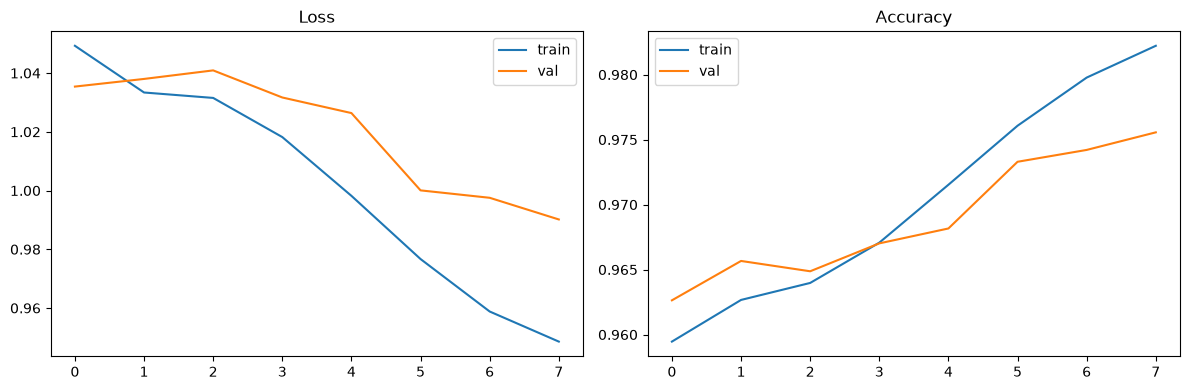

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()


In [ ]:
best = torch.load(BEST_CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(best["state_dict"])
test_loss, test_acc = run_epoch(model, test_loader, device, criterion)
print(f"Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")
print(f"Saved {BEST_CHECKPOINT.name} -- use with: python predict_word.py word.png --model {BEST_CHECKPOINT.name}")
